In [ ]:
# ── CARGA Y MAPEOS ─────────────────────────────────────────────
df = pd.read_csv('/defunciones_deis.csv', sep=';', encoding='utf-8-sig')
df = df.rename(columns={
    'PROVRES':'cod_provincia','SEXO':'cod_sexo','CAUSA':'cod_causa',
    'MAT':'tipo_muerte','GRUPEDAD':'grupo_edad','CUENTA':'defunciones'
})
df_general = df[df['tipo_muerte'].isnull()].copy()

provincias = {
    2:'CABA', 6:'Buenos Aires', 10:'Catamarca', 14:'Córdoba',
    18:'Corrientes', 22:'Chaco', 26:'Chubut', 30:'Entre Ríos',
    34:'Formosa', 38:'Jujuy', 42:'La Pampa', 46:'La Rioja',
    50:'Mendoza', 54:'Misiones', 58:'Neuquén', 62:'Río Negro',
    66:'Salta', 70:'San Juan', 74:'San Luis', 78:'Santa Cruz',
    82:'Santa Fe', 86:'Santiago del Estero', 90:'Tucumán',
    94:'Tierra del Fuego', 98:'Extranjero', 99:'Sin especificar'
}
sexo_map = {1:'Masculino', 2:'Femenino', 3:'Indeterminado', 9:'Sin especificar'}
capitulos_cie = {
    'A':'Infecciosas','B':'Infecciosas','C':'Tumores malignos',
    'D':'Tumores benignos','E':'Endocrinas','F':'Trastornos mentales',
    'G':'Sist. nervioso','I':'Sist. circulatorio','J':'Sist. respiratorio',
    'K':'Sist. digestivo','N':'Sist. genitourinario','O':'Embarazo/parto',
    'P':'Perinatal','Q':'Malformaciones','R':'Síntomas mal definidos',
    'V':'Accid. transporte','W':'Caídas/ahogam.','X':'Causas externas',
    'Y':'Causas externas','Z':'Otros factores'
}
causas_labels = {
    'J18':'Neumonía','I50':'Insuf. cardíaca','R99':'Causas mal definidas',
    'I21':'Infarto agudo','J96':'Insuf. respiratoria','A41':'Sepsis',
    'C34':'T.M. pulmón','I47':'Taquicardia parox.','I64':'ACV',
    'C18':'T.M. colon','I49':'Arritmia','E14':'Diabetes',
    'C50':'T.M. mama','J44':'EPOC','N39':'Inf. urinaria',
    'X70':'Suicidio','Y20':'Int. no determinada','Y34':'Int. no determinada (otras)',
    'X95':'Agresión por arma de fuego','X59':'Exposición factores no espec.',
    'V23':'Accidente de moto','Y24':'Disparo no determinado',
}

df_general['provincia']   = df_general['cod_provincia'].map(provincias)
df_general['sexo']        = df_general['cod_sexo'].map(sexo_map)
df_general['edad_orden']  = df_general['grupo_edad'].str.extract(r'^(\d+)').astype(int)
df_general['edad_label']  = df_general['grupo_edad'].str.replace(r'^\d+[\.\s]*', '', regex=True).str.strip()
df_general['capitulo']    = df_general['cod_causa'].str[0].map(capitulos_cie)

sns.set_theme(style='whitegrid', palette='muted')

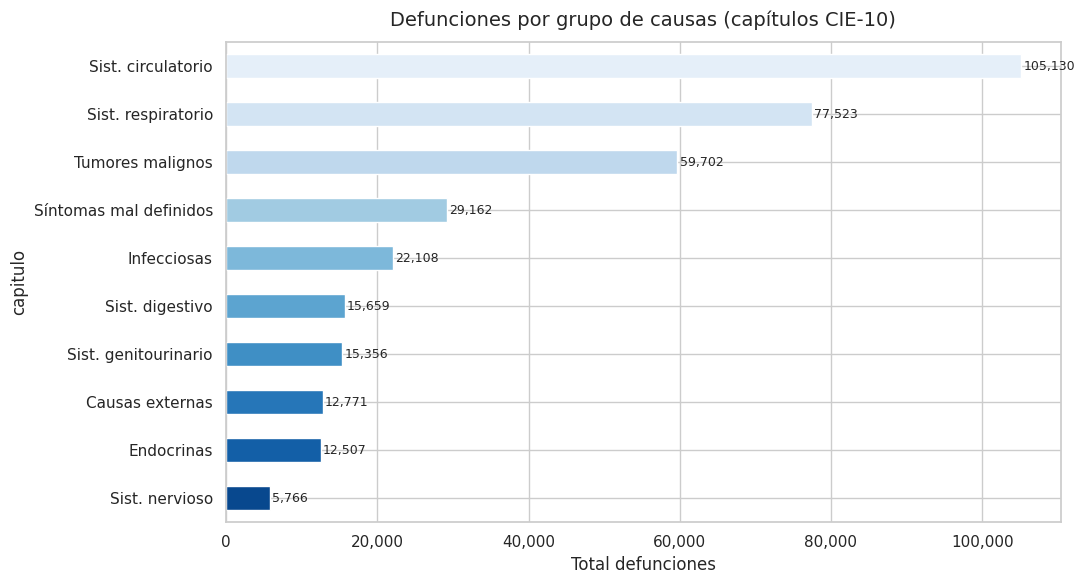

In [ ]:
# ── VIZ 1: GRANDES GRUPOS DE CAUSAS (capítulos CIE-10) ────────
caps = (df_general.groupby('capitulo')['defunciones'].sum()
        .sort_values(ascending=False)
        .dropna().head(10))

fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette('Blues_r', len(caps))
caps.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Defunciones por grupo de causas (capítulos CIE-10)', fontsize=14, pad=12)
ax.set_xlabel('Total defunciones')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(caps.sort_values()):
    ax.text(v + 300, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/grupos_causas_cie.png', dpi=150)
plt.show()

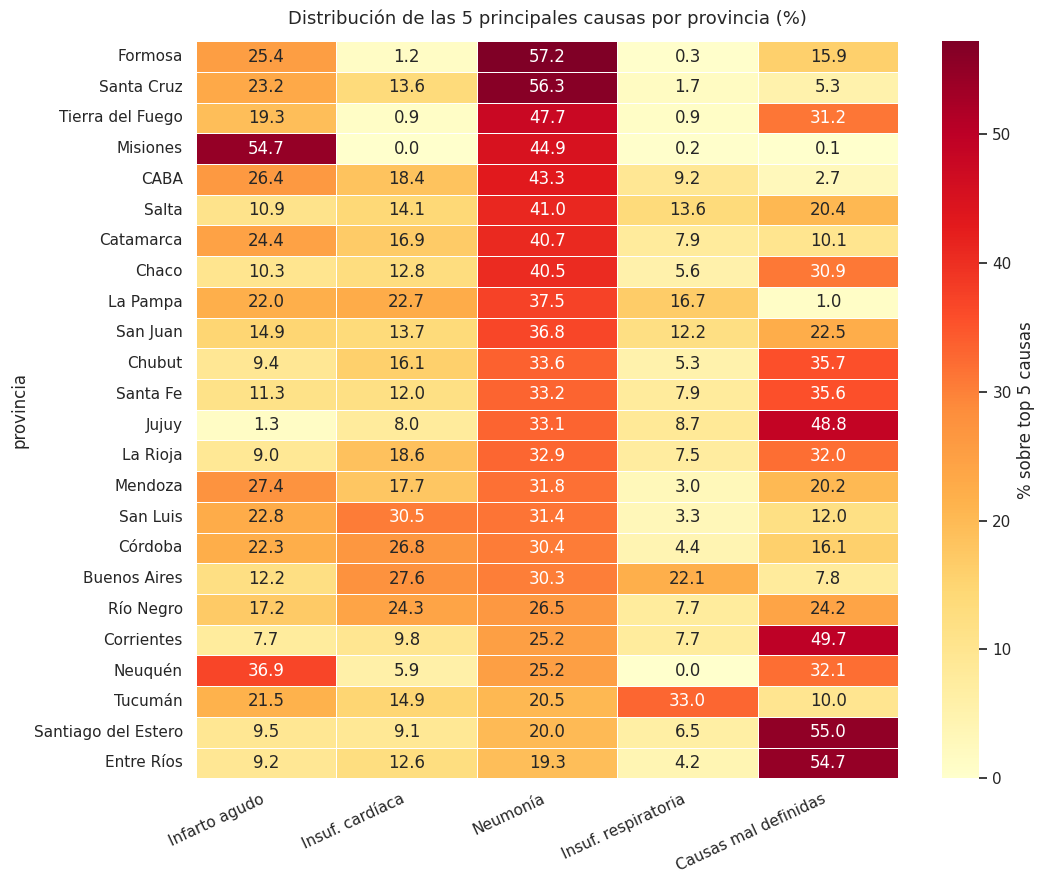

In [ ]:
# ── VIZ 2: HEATMAP — TOP 5 CAUSAS POR PROVINCIA ───────────────
excluir_prov = ['Sin especificar', 'Extranjero']
top5_cods = df_general.groupby('cod_causa')['defunciones'].sum().nlargest(5).index.tolist()

pivot_prov = (df_general[
    ~df_general['provincia'].isin(excluir_prov) &
    df_general['cod_causa'].isin(top5_cods)]
    .groupby(['provincia','cod_causa'])['defunciones'].sum()
    .unstack(fill_value=0))

pivot_prov.columns = [causas_labels.get(c, c) for c in pivot_prov.columns]

# Normalizar por fila para comparar proporciones entre provincias
pivot_norm = pivot_prov.div(pivot_prov.sum(axis=1), axis=0) * 100
pivot_norm = pivot_norm.sort_values('Neumonía', ascending=False)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(pivot_norm, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': '% sobre top 5 causas'})
ax.set_title('Distribución de las 5 principales causas por provincia (%)', fontsize=13, pad=12)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/heatmap_causas_provincia.png', dpi=150)
plt.show()

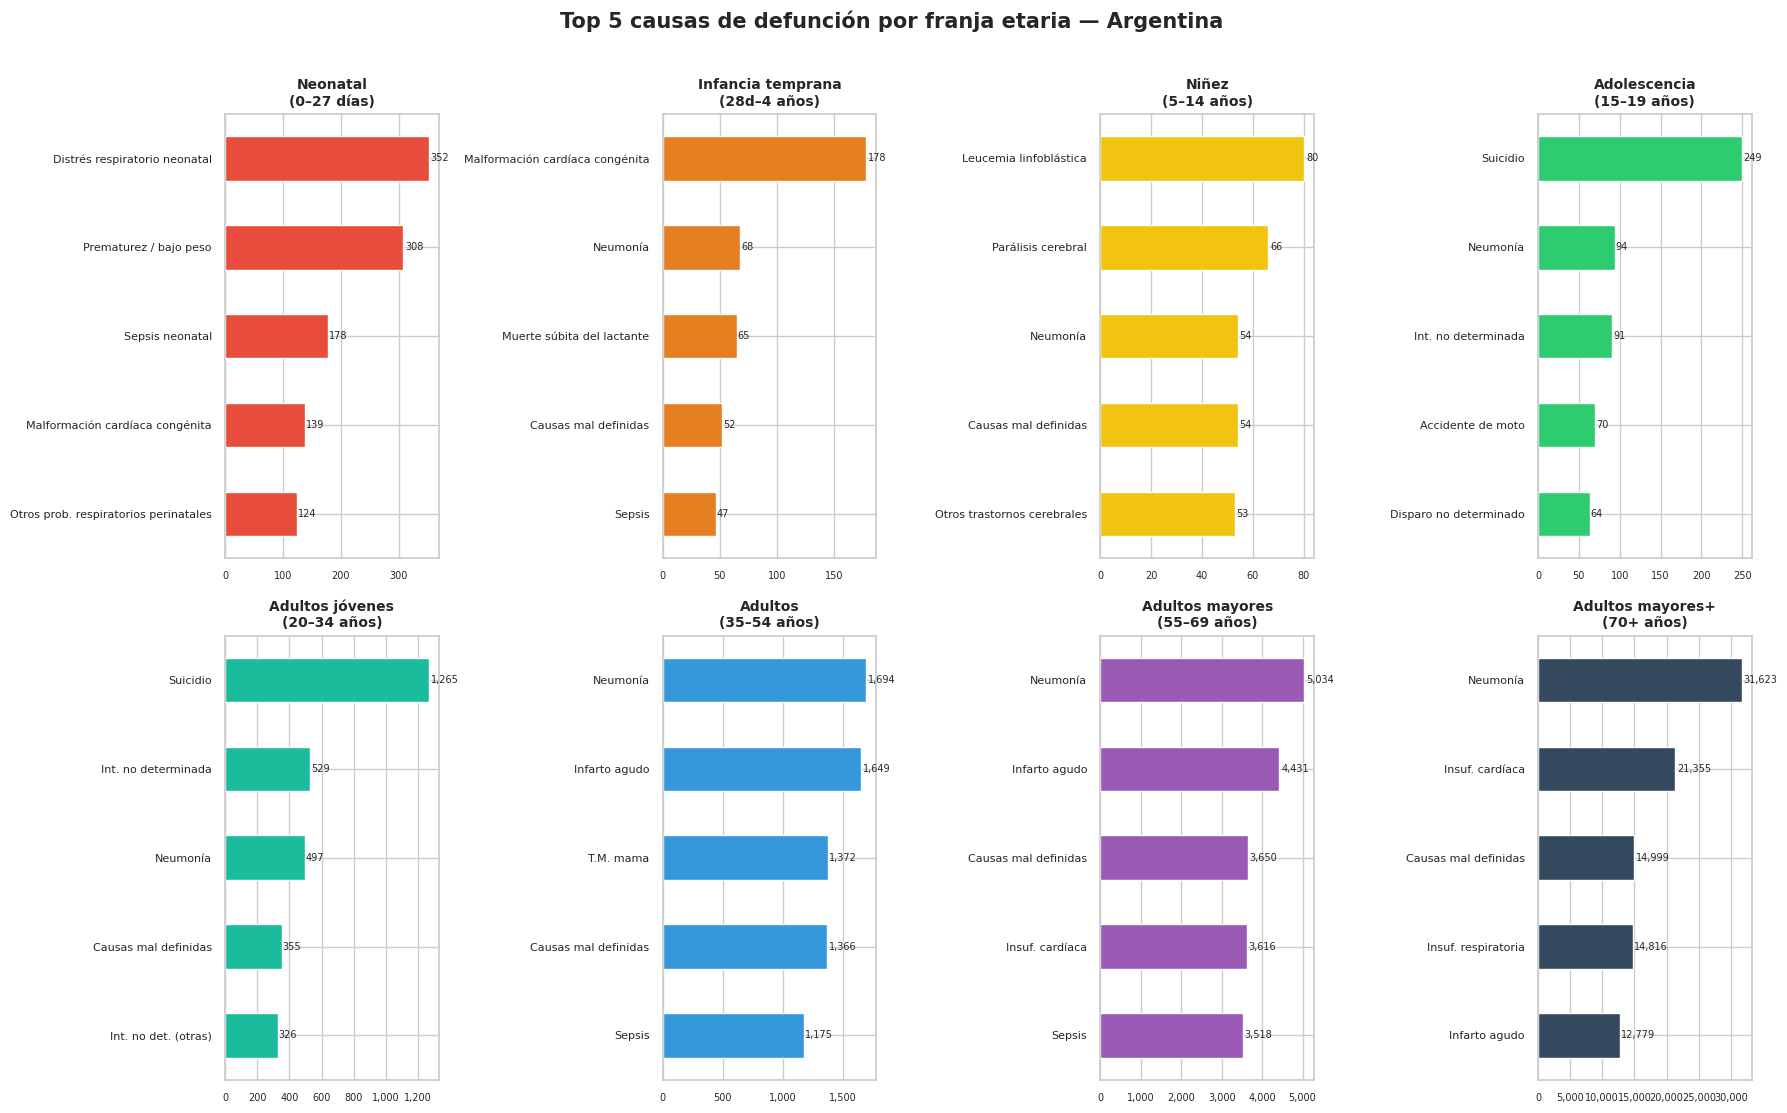

In [ ]:
# ── VIZ 3: TOP 5 CAUSAS POR FRANJA ETARIA ─────────────────────

# ── FRANJAS ETARIAS (definición) ──────────────────────────────
franjas = [
    ('Neonatal\n(0–27 días)',           [1, 2]),
    ('Infancia temprana\n(28d–4 años)', [3, 4, 5, 6, 7]),
    ('Niñez\n(5–14 años)',              [8, 9]),
    ('Adolescencia\n(15–19 años)',      [10]),
    ('Adultos jóvenes\n(20–34 años)',   [11, 12, 13]),
    ('Adultos\n(35–54 años)',           [14, 15, 16, 17]),
    ('Adultos mayores\n(55–69 años)',   [18, 19, 20]),
    ('Adultos mayores+\n(70+ años)',    [21, 22, 23, 24]),
]

excluir_edad = [31, 25]
df_edad = df_general[~df_general['edad_orden'].isin(excluir_edad)].copy()


fig, axes = plt.subplots(2, 4, figsize=(18, 11))
axes = axes.flatten()
colores = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6','#34495e']

for idx, (titulo, ordenes) in enumerate(franjas):
    ax = axes[idx]
    subset = df_edad[df_edad['edad_orden'].isin(ordenes)]
    top5 = subset.groupby('cod_causa')['defunciones'].sum().nlargest(5)
    top5.index = [causas_labels.get(c, c) for c in top5.index]
    top5 = top5.sort_values()

    top5.plot(kind='barh', ax=ax, color=colores[idx], edgecolor='white')
    ax.set_title(titulo, fontsize=10, fontweight='bold', pad=6)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=7)
    for i, v in enumerate(top5):
        ax.text(v * 1.01, i, f'{v:,}', va='center', fontsize=7)

fig.suptitle('Top 5 causas de defunción por franja etaria — Argentina',
             fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/causas_por_franja_etaria.png', dpi=150, bbox_inches='tight')
plt.show()

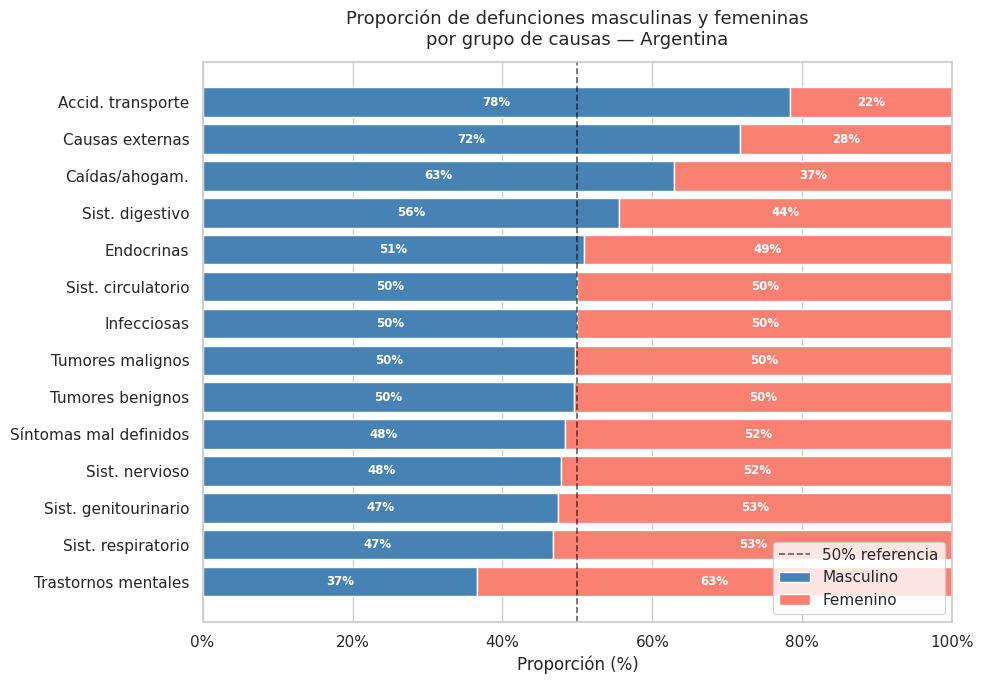

In [ ]:
# ── VIZ 4: PROPORCIÓN M/F POR GRUPO DE CAUSAS (barras 100%) ───
df_mf = df_general[df_general['sexo'].isin(['Masculino','Femenino'])]
caps_sexo = (df_mf.groupby(['capitulo','sexo'])['defunciones']
             .sum().unstack(fill_value=0))
caps_sexo = caps_sexo[caps_sexo.sum(axis=1) > 2000].copy()

total    = caps_sexo.sum(axis=1)
caps_pct = caps_sexo.div(total, axis=0) * 100
caps_pct = caps_pct.sort_values('Masculino', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(caps_pct.index, caps_pct['Masculino'], color='steelblue', label='Masculino', edgecolor='white')
ax.barh(caps_pct.index, caps_pct['Femenino'],  left=caps_pct['Masculino'],
        color='salmon', label='Femenino', edgecolor='white')
ax.axvline(50, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label='50% referencia')

for i, (_, row) in enumerate(caps_pct.iterrows()):
    if row['Masculino'] > 8:
        ax.text(row['Masculino'] / 2, i, f"{row['Masculino']:.0f}%",
                va='center', ha='center', fontsize=8.5, color='white', fontweight='bold')
    if row['Femenino'] > 8:
        ax.text(row['Masculino'] + row['Femenino'] / 2, i, f"{row['Femenino']:.0f}%",
                va='center', ha='center', fontsize=8.5, color='white', fontweight='bold')

ax.set_xlim(0, 100)
ax.set_xlabel('Proporción (%)')
ax.set_title('Proporción de defunciones masculinas y femeninas\npor grupo de causas — Argentina',
             fontsize=13, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/figures/proporcion_sexo_causas.png', dpi=150)
plt.show()